In [1]:
!pip install yellowbrick
import os
os.environ["OMP_NUM_THREADS"] = '2'
import numpy as np 
import pandas as pd
import pickle
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from IPython.display import display
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Defaulting to user installation because normal site-packages is not writeable


# Get File

In [2]:
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')

print(f"Ready for clustering with {X_train_scaled.shape[1]} features.")

Ready for clustering with 39 features.


# K-means model creation


In [4]:
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')

print(f"Using all {X_train_scaled.shape[1]} features for clustering")

kmeans_full = KMeans(n_clusters=3, random_state=42, n_init=25, max_iter=500)
kmeans_full.fit(X_train_scaled)

os.makedirs('../artifacts', exist_ok=True)
joblib.dump(kmeans_full, '../artifacts/kmeans_model.pkl')

print("K-Means model saved with all 39 features")

clusters = kmeans_full.predict(X_train_scaled)
print(f"\nCluster distribution:")
for i in range(3):
    count = (clusters == i).sum()
    pct = count / len(clusters) * 100
    print(f"  Cluster {i}: {count:,} patients ({pct:.1f}%)")

Using all 39 features for clustering
K-Means model saved with all 39 features

Cluster distribution:
  Cluster 0: 22,198 patients (33.3%)
  Cluster 1: 24,470 patients (36.7%)
  Cluster 2: 19,920 patients (29.9%)


In [5]:
X_train_unscaled = pd.read_csv('../data/processed/X_train.csv')
X_train_unscaled['Cluster'] = clusters

key_features = [
    'Age', 'gender', 'bmi', 'hba1c', 'glucose_fasting', 'glucose_postprandial',
    'physical_activity_minutes_per_week', 'diet_score',
    'family_history_diabetes', 'hypertension_history', 'cardiovascular_history',
    'systolic_bp', 'cholesterol_total'
]

print("="*60)
print("CLUSTER PROFILES - Mean Values")
print("="*60)

cluster_profile = X_train_unscaled.groupby('Cluster')[key_features].mean()
cluster_profile['Patient_Count'] = X_train_unscaled['Cluster'].value_counts().sort_index()
cluster_profile['Percentage'] = (cluster_profile['Patient_Count'] / len(X_train_unscaled) * 100).round(1)

cluster_profile_sorted = cluster_profile.sort_values('hba1c', ascending=True)

risk_labels = ['Low Risk', 'Moderate Risk', 'High Risk']
for i, (idx, row) in enumerate(cluster_profile_sorted.iterrows()):
    print(f"\nCluster {idx} → {risk_labels[i]}")
    print(f"  HbA1c: {row['hba1c']:.2f}%")
    print(f"  Glucose (fasting): {row['glucose_fasting']:.1f} mg/dL")
    print(f"  Age: {row['Age']:.1f} years")
    print(f"  BMI: {row['bmi']:.1f}")
    print(f"  Physical activity: {row['physical_activity_minutes_per_week']:.1f} min/week")
    print(f"  Family history: {row['family_history_diabetes']:.1%}")
    print(f"  Patients: {row['Patient_Count']:,} ({row['Percentage']}%)")

display(cluster_profile_sorted.round(2))

CLUSTER PROFILES - Mean Values

Cluster 1 → Low Risk
  HbA1c: 5.86%
  Glucose (fasting): 100.9 mg/dL
  Age: 44.1 years
  BMI: 24.2
  Physical activity: 135.1 min/week
  Family history: 8.5%
  Patients: 24,470.0 (36.7%)

Cluster 0 → Moderate Risk
  HbA1c: 6.67%
  Glucose (fasting): 114.4 mg/dL
  Age: 57.6 years
  BMI: 28.3
  Physical activity: 112.2 min/week
  Family history: 18.6%
  Patients: 22,198.0 (33.3%)

Cluster 2 → High Risk
  HbA1c: 7.16%
  Glucose (fasting): 119.8 mg/dL
  Age: 49.3 years
  BMI: 24.4
  Physical activity: 106.9 min/week
  Family history: 41.5%
  Patients: 19,920.0 (29.9%)


,Age,gender,bmi,hba1c,glucose_fasting,glucose_postprandial,physical_activity_minutes_per_week,diet_score,family_history_diabetes,hypertension_history,cardiovascular_history,systolic_bp,cholesterol_total,Patient_Count,Percentage
Cluster,,,,,,,,,,,,,,,
1,44.05,0.48,24.16,5.86,100.93,136.52,135.14,6.24,0.09,0.21,0.06,110.66,175.53,24470,36.7
0,57.63,0.48,28.35,6.67,114.36,164.83,112.20,5.60,0.19,0.30,0.11,123.28,207.92,22198,33.3
2,49.28,0.47,24.41,7.16,119.85,183.26,106.91,6.12,0.42,0.25,0.08,113.67,174.38,19920,29.9


# Calculate distrobution and mean values for each cluster feature

In [10]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')

clusters = kmeans_full.predict(X_train_scaled)

X_train['Cluster'] = clusters

print("=" * 60)
print("CLUSTER DISTRIBUTION")
print("=" * 60)
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = count / len(clusters) * 100
    print(f"Cluster {cluster}: {count:,} patients ({pct:.1f}%)")

print("\n" + "=" * 60)
print("CLUSTER PROFILES - Mean Values")
print("=" * 60)

key_features = [
    'Age', 'gender', 'bmi', 'hba1c', 'glucose_fasting', 'glucose_postprandial',
    'physical_activity_minutes_per_week', 'diet_score', 'systolic_bp',
    'family_history_diabetes', 'hypertension_history'
]

cluster_profile = X_train.groupby('Cluster')[key_features].mean()
cluster_profile['Patient_Count'] = cluster_counts
cluster_profile['Percentage'] = (cluster_profile['Patient_Count'] / len(X_train) * 100).round(1)

cluster_profile_sorted = cluster_profile.sort_values('hba1c')

print("\nClusters sorted by HbA1c (lowest to highest risk):")
display(cluster_profile_sorted.round(3))

risk_labels = ['Low Risk', 'Moderate Risk', 'High Risk']
cluster_mapping = {}
for i, (idx, _) in enumerate(cluster_profile_sorted.iterrows()):
    cluster_mapping[idx] = risk_labels[i]
    print(f"Cluster {idx} → {risk_labels[i]} (HbA1c: {cluster_profile_sorted.loc[idx, 'hba1c']:.2f}%)")

import pickle

cluster_mapping = {
    1: 'Low Risk',
    0: 'Moderate Risk', 
    2: 'High Risk'
}

with open('../artifacts/cluster_labels.pkl', 'wb') as f:
    pickle.dump(cluster_mapping, f)

print("Cluster labels saved:", cluster_mapping)

CLUSTER DISTRIBUTION
Cluster 0: 22,198 patients (33.3%)
Cluster 1: 24,470 patients (36.7%)
Cluster 2: 19,920 patients (29.9%)

CLUSTER PROFILES - Mean Values

Clusters sorted by HbA1c (lowest to highest risk):


,Age,gender,bmi,hba1c,glucose_fasting,glucose_postprandial,physical_activity_minutes_per_week,diet_score,systolic_bp,family_history_diabetes,hypertension_history,Patient_Count,Percentage
Cluster,,,,,,,,,,,,,
1,44.055,0.478,24.155,5.864,100.933,136.522,135.144,6.241,110.659,0.085,0.207,24470,36.7
0,57.634,0.479,28.345,6.668,114.356,164.832,112.197,5.597,123.275,0.186,0.303,22198,33.3
2,49.282,0.474,24.412,7.155,119.850,183.263,106.910,6.119,113.669,0.415,0.248,19920,29.9


Cluster 1 → Low Risk (HbA1c: 5.86%)
Cluster 0 → Moderate Risk (HbA1c: 6.67%)
Cluster 2 → High Risk (HbA1c: 7.16%)
Cluster labels saved: {1: 'Low Risk', 0: 'Moderate Risk', 2: 'High Risk'}


# Scatter plots

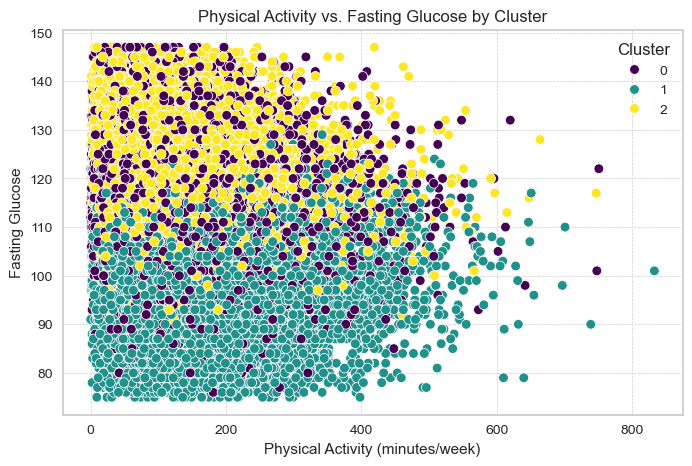

In [7]:
plt.figure(figsize=(8, 5))

# Using the exact names from your X_train.columns output
sns.scatterplot(
    data=X_train,
    x="physical_activity_minutes_per_week", 
    y="glucose_fasting", 
    hue="Cluster",
    palette="viridis"
)

plt.xlabel("Physical Activity (minutes/week)")
plt.ylabel("Fasting Glucose")
plt.title("Physical Activity vs. Fasting Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()


The scatter plot show clear seperation mainly by fasting glucose . cluster 1  has the highest glucose value (high-risk group) ,Cluster 0 has the lowest glucose values(low-risk group) , and Cluster 2 falls in between (moderate risk) . Physical activity overlaps across clusters ,meaning glucose is the strongest factor driving the segmentation 

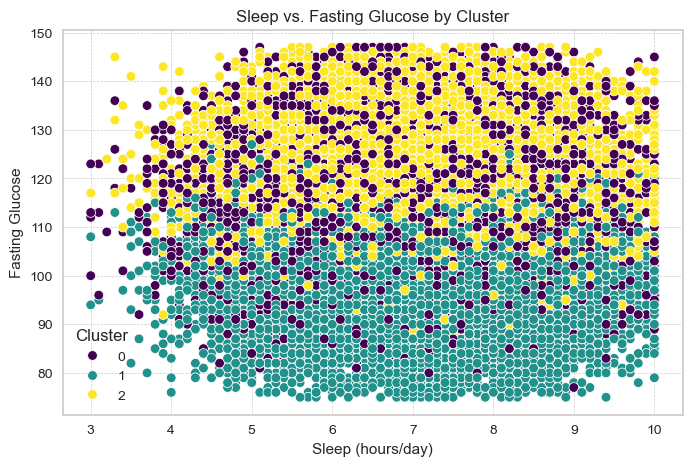

In [8]:
plt.figure(figsize=(8, 5))

# Using the exact names from your X_train output
sns.scatterplot(
    data=X_train,
    x="sleep_hours_per_day",
    y="glucose_fasting",
    hue="Cluster",
    palette="viridis"
)

plt.xlabel("Sleep (hours/day)")
plt.ylabel("Fasting Glucose")
plt.title("Sleep vs. Fasting Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Fasting glucose clearly seperates the clusters , while sleep hours overlap across all groups. Cluster 1 shows shows consistently higher glucose (high-risk),Cluster 0 lower glucose (low-risk),and Cluster 2 moderate levels . This suggests that sleep is not strong clustering factor compared to glucose

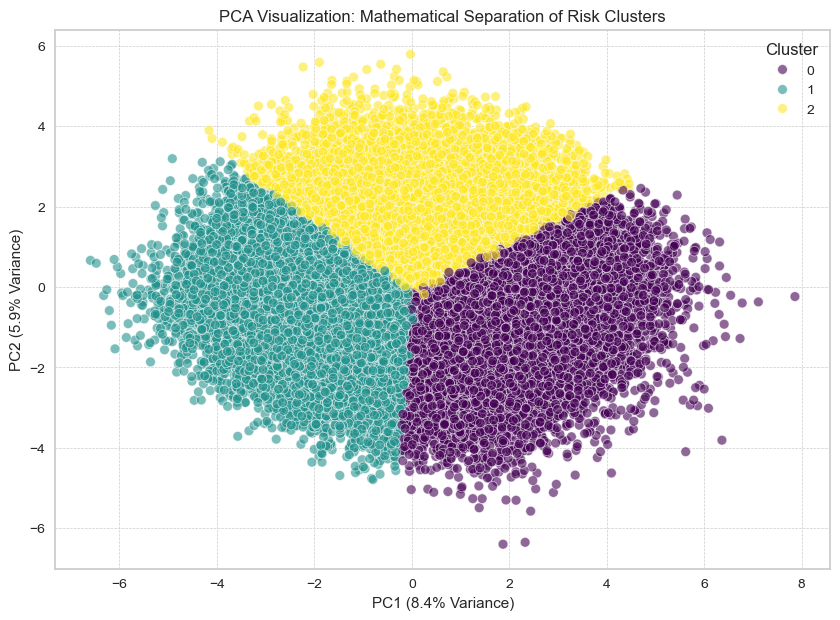

Total variance explained by 2 components: 14.2%
WHAT FEATURES DRIVE EACH COMPONENT?

 Top 8 features driving PC1 (horizontal spread):
   bmi: patients with higher values → move RIGHT (weight: 0.344)
   hba1c: patients with higher values → move RIGHT (weight: 0.339)
   glucose_fasting: patients with higher values → move RIGHT (weight: 0.337)
   glucose_postprandial: patients with higher values → move RIGHT (weight: 0.313)
   ldl_cholesterol: patients with higher values → move RIGHT (weight: 0.308)
   waist_to_hip_ratio: patients with higher values → move RIGHT (weight: 0.302)
   cholesterol_total: patients with higher values → move RIGHT (weight: 0.286)
   Age: patients with higher values → move RIGHT (weight: 0.258)

 Top 8 features driving PC2 (vertical spread):
   hba1c: patients with higher values → move UP (weight: 0.472)
   glucose_postprandial: patients with higher values → move UP (weight: 0.457)
   glucose_fasting: patients with higher values → move UP (weight: 0.373)
   family

In [9]:
from sklearn.decomposition import PCA

X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_train = pd.read_csv('../data/processed/X_train.csv')

all_features = X_train_scaled.columns.tolist()

clusters_scaled = kmeans_full.predict(X_train_scaled)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters_scaled

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Cluster", 
    palette="viridis", 
    alpha=0.6
)

plt.title("PCA Visualization: Mathematical Separation of Risk Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

print("=" * 60)
print("WHAT FEATURES DRIVE EACH COMPONENT?")
print("=" * 60)

n_top = 8
pca_components = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=all_features
)

print(f"\n Top {n_top} features driving PC1 (horizontal spread):")
pc1_sorted = pca_components['PC1'].sort_values(ascending=False)
for feature in pc1_sorted.head(n_top).index:
    weight = pc1_sorted[feature]
    direction = "higher" if weight > 0 else "lower"
    print(f"   {feature}: patients with {direction} values → move RIGHT (weight: {weight:.3f})")

print(f"\n Top {n_top} features driving PC2 (vertical spread):")
pc2_sorted = pca_components['PC2'].sort_values(ascending=False)
for feature in pc2_sorted.head(n_top).index:
    weight = pc2_sorted[feature]
    direction = "higher" if weight > 0 else "lower"
    print(f"   {feature}: patients with {direction} values → move UP (weight: {weight:.3f})")

print("\n" + "=" * 60)
print("CLINICAL VALIDATION - Mean Values by Cluster")
print("=" * 60)

X_train['Cluster'] = clusters_scaled

key_metrics = ['hba1c', 'glucose_fasting', 'Age', 'bmi', 'physical_activity_minutes_per_week', 'family_history_diabetes']
cluster_means = X_train.groupby('Cluster')[key_metrics].mean()

cluster_means['Patient_Count'] = X_train['Cluster'].value_counts().sort_index()
cluster_means['Percentage'] = (cluster_means['Patient_Count'] / len(X_train) * 100).round(1)

cluster_means = cluster_means.sort_values('hba1c')

cluster_means['Risk_Level'] = ['Low Risk', 'Moderate Risk', 'High Risk']

print(cluster_means.round(3))

In [12]:
import pandas as pd
import pickle
import joblib

X_train = pd.read_csv('../data/processed/X_train.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
kmeans_full = joblib.load('../artifacts/kmeans_model.pkl')

clusters = kmeans_full.predict(X_train_scaled)
X_train['Cluster'] = clusters

cluster_means = {}
for cluster in [0, 1, 2]:
    cluster_data = X_train[X_train['Cluster'] == cluster]
    cluster_means[cluster] = cluster_data.mean().to_dict()

with open('../artifacts/cluster_means.pkl', 'wb') as f:
    pickle.dump(cluster_means, f)

print("Cluster means saved for clusters 0, 1, 2")

Cluster means saved for clusters 0, 1, 2
